[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A3_credit_risk_scorecards.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's third appendix (see `README.md`), written like the module's core notebooks. Core course stack only (`pandas`, `numpy`, `scikit-learn`, `matplotlib`); all data generated inline — 100 % offline.

---
# 📓 Notebook A3 (IA) — Credit Risk: Scorecards, Expected Loss & the Approve/Decline Decision

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

Lending is the oldest applied-statistics job there is, and it has two features nothing else in this module has.

**The first is that the deliverable is a document, not a model.** A credit committee has to sign the thing, a regulator may ask to see it, and a declined applicant may be entitled to know *why*. So the industry's workhorse is not a gradient-boosted ensemble; it is a **scorecard** — a table of points you could print on one page and hand to someone. We will build one, and then check honestly whether the ensemble beats it.

**The second is that the training labels are a product of your own past decisions.** You only find out whether a customer repays if you *approved* them. Every applicant you declined is a permanent question mark. NB 24 flagged this as the "selective labels" problem in a single stretch exercise; here it is §6, it costs six figures, and it is the reason credit teams deliberately approve a few applications they believe are bad.

> 🧠 **Mental model.** In lending you earn a thin slice per period and can lose the entire exposure once. A 30-day cycle on a €5,000 limit at 12 % margin earns €600; a default costs €3,250. That asymmetry — not the model's AUC — is what sets the cutoff, and it is why `PD* = m/(m + LGD)` is the only formula in this notebook you must remember.

## 🎯 Learning objectives

By the end you can:

1. Build a **WOE/IV scorecard** end-to-end — binning, information value, the logistic fit, the sign check, and the points transform with its PDO convention.
2. Say honestly when a **scorecard beats a gradient-boosted model** and when it doesn't, and why the industry ships the scorecard anyway.
3. Explain why credit decisions need **calibration**, not just ranking, and check it.
4. Derive the profit-optimal cutoff **PD\* = m/(m + LGD)** from expected loss, and read a profit curve without over-reading its argmax.
5. Set **credit limits** as a risk-appetite overlay and state what that overlay costs in expected profit.
6. Diagnose the **selective-labels** problem, quantify what it costs, and price a randomized exploration budget as the fix.

## ✅ Prerequisites

**NB 17–19** (classifiers, evaluation, leakage) and **NB 18** especially for calibration. **NB 23** for the expected-value decision pattern; **A1** for the "flat near the optimum" lesson, which reappears in §4; **A2** if you want §6's exploration budget to land. All data is generated inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 130)
print("Setup OK")

Setup OK


## 1. The business: "Invoice 30", and what a bad decision costs

The **B2B webshop** (NB 25, A1, A2) sells office and IT supplies. Its biggest growth lever is not a discount, it is **trade credit**: let a business customer order now and pay in 30 days. Customers love it, it wins share of wallet — and it means the webshop is now, whether it likes it or not, a lender.

Two years of applications are on file. For each one you have what the credit team collected at application time:

| Field | What it is |
|---|---|
| `months_trading` | how long the company has existed |
| `annual_revenue_k` | self-reported turnover, €000s |
| `requested_limit` | the credit line they asked for |
| `monthly_sales` | revenue / 12, for scale |
| `limit_to_monthly_sales` | **the exposure ratio** — how much credit they want relative to what they sell |
| `prior_late_payments` | late payments on file |
| `sector` | Professional / Retail / Manufacturing / Construction |
| `director_changes` | board churn in the last 3 years |
| `payment_score` | a **credit-bureau score**, 5–100, higher is safer |
| `default` | *outcome:* invoice still unpaid at 90 days past due |

### The economics, which decide everything

- **LGD** (loss given default) = **65 %**. On default you recover about a third — some stock comes back, some is collected.
- **Margin** = **12 %** of the credit-funded order value per 30-day cycle, net of servicing and the cost of capital.
- **EAD** (exposure at default) = the granted limit; assume it is drawn when things go wrong, because it is.

So per cycle, on a granted limit *L*: you earn `0.12 · L` if they pay, and lose `0.65 · L` if they don't. **You need roughly five good cycles to pay for one default.** Hold on to that ratio — §4 turns it into the cutoff.

In [2]:
LGD, MARGIN = 0.65, 0.12
PD_STAR = MARGIN / (MARGIN + LGD)
print(f"break-even PD = margin / (margin + LGD) = {MARGIN} / ({MARGIN} + {LGD}) "
      f"= {PD_STAR:.4f}  ->  {PD_STAR:.1%}")
print(f"good cycles needed to pay for one default: {LGD / MARGIN:.1f}")

break-even PD = margin / (margin + LGD) = 0.12 / (0.12 + 0.65) = 0.1558  ->  15.6%
good cycles needed to pay for one default: 5.4


In [3]:
N = 6000
SECTORS = ["Professional", "Retail", "Manufacturing", "Construction"]
SECTOR_RISK = dict(zip(SECTORS, [-0.55, 0.15, 0.00, 0.85]))
NUM = ["months_trading", "annual_revenue_k", "limit_to_monthly_sales",
       "prior_late_payments", "director_changes", "payment_score"]
ALL_COLS = NUM + ["sector"]

def build_applications(seed=5, intercept=-2.95, noise=0.45, bureau_noise=0.55, n=N):
    rng = np.random.default_rng(seed)
    months = np.clip(rng.gamma(2.2, 26, n), 2, 300).round()
    revenue_k = np.exp(rng.normal(np.log(420), 0.95, n)).round(1)
    sector = rng.choice(SECTORS, n, p=[0.34, 0.28, 0.22, 0.16])
    director_changes = rng.poisson(0.35, n)
    monthly_sales = revenue_k * 1000 / 12
    requested = (np.clip(rng.gamma(2.0, 0.13, n), 0.03, 1.1) * monthly_sales).round(-1)
    ratio = requested / monthly_sales

    # A credit bureau sees company AGE and SIZE (and payment behaviour).
    visible = -0.010 * months - 0.55 * np.log(revenue_k / 420)
    # It does NOT see how much credit they are asking for relative to their sales,
    # boardroom churn, or sector cyclicality -- and those carry most of the risk.
    hidden = (1.9 * ratio + 0.75 * director_changes
              + np.array([SECTOR_RISK[s] for s in sector]))

    latent = intercept + visible + hidden + rng.normal(0, noise, n)
    pd_true = 1 / (1 + np.exp(-latent))                      # the hidden truth
    late = rng.poisson(np.clip(0.15 + 9 / (1 + np.exp(-(intercept + visible))), 0.05, 8))
    bureau_pd = 1 / (1 + np.exp(-(intercept + visible + rng.normal(0, bureau_noise, n))))

    df = pd.DataFrame(dict(
        months_trading=months.astype(int), annual_revenue_k=revenue_k,
        requested_limit=requested, monthly_sales=monthly_sales.round(-1),
        limit_to_monthly_sales=ratio.round(3), prior_late_payments=late,
        sector=sector, director_changes=director_changes,
        payment_score=np.clip(np.round(92 - 300 * bureau_pd), 5, 100).astype(int),
        pd_true=pd_true, default=rng.binomial(1, pd_true)))
    # The credit committee's judgemental rulebook, in force for the last two years.
    df["approved"] = ((df.payment_score >= 62) & (df.months_trading >= 18)
                      & (df.limit_to_monthly_sales <= 0.55)
                      & (df.director_changes < 2)).astype(int)
    return df

apps = build_applications()
approved_mask = apps.approved == 1
print(apps[["months_trading", "annual_revenue_k", "requested_limit",
            "limit_to_monthly_sales", "prior_late_payments", "sector",
            "payment_score", "approved", "default"]].head(4).to_string(index=False))

 months_trading  annual_revenue_k  requested_limit  limit_to_monthly_sales  prior_late_payments        sector  payment_score  approved  default
             25             133.5           5250.0                   0.472                    2        Retail             66         1        1
             40             449.4          17290.0                   0.462                    0  Professional             68         1        0
            101            2230.6          67550.0                   0.363                    0 Manufacturing             90         1        0
             31             930.4          36600.0                   0.472                    0  Professional             68         1        0


In [4]:
print(f"applications                {len(apps):>7,}")
print(f"approved by the legacy rule {approved_mask.mean():>7.1%}")
print(f"default rate -- approved    {apps.default[approved_mask].mean():>7.2%}   <- what the P&L shows")
print(f"default rate -- declined    {apps.default[~approved_mask].mean():>7.2%}   <- NEVER OBSERVED in reality")
print(f"default rate -- everyone    {apps.default.mean():>7.2%}")
print(f"\nannual credit losses on the current book: "
      f"{LGD * (apps.requested_limit[approved_mask] * apps.default[approved_mask]).sum() / 2:>12,.0f} EUR")

applications                  6,000
approved by the legacy rule   75.8%
default rate -- approved      6.92%   <- what the P&L shows
default rate -- declined     15.11%   <- NEVER OBSERVED in reality
default rate -- everyone      8.90%

annual credit losses on the current book:    1,016,320 EUR


The finance director's complaint is the **6.92 %** default rate on the approved book — high enough that the losses are visible in the P&L. Their instinct is "tighten the rules."

The number underneath it is the more interesting one. The declined applicants defaulted at **15.11 %** — but *we only know that because this is a simulation*. In a real credit shop that column does not exist: you never find out what the applicants you turned away would have done. Almost everything in §6 follows from that missing column, and it is worth noticing now that the legacy rule *did* separate good from bad (6.92 % vs 15.11 %). It is not a stupid rule. It is a rule with blind spots — and blind spots are what a model is for.

## 2. WOE, IV, and the scorecard you can print

A **scorecard** does something that looks archaic and turns out to be shrewd: it throws away the exact value of every variable and keeps only which *bin* the applicant fell into. `months_trading = 47` becomes "in the 32–64 month band, worth +3 points."

Why any sane person would do this:

- **Monotone, explainable, auditable.** Each bin's contribution is a number you can defend to a committee and quote in a decline letter.
- **Non-linearity for free**, without ever writing an interaction term.
- **Outliers and missing values become bins**, so a self-reported turnover of €40 million does not blow up the model — it lands in the top band.
- **Stability.** Bin populations drift slowly and are easy to monitor; a continuous feature's distribution shift is much harder to see.

The bin's numeric value is its **weight of evidence**:

$$\text{WOE}_b = \ln\!\frac{\text{share of GOODS in bin } b}{\text{share of BADS in bin } b}$$

Positive WOE = safer than average. Summed over bins, weighted by how much of the population each holds, you get the feature's **information value**:

$$\text{IV} = \sum_b (\text{good}_b - \text{bad}_b)\,\text{WOE}_b$$

with the industry's rules of thumb: **< 0.02 useless · 0.02–0.1 weak · 0.1–0.3 medium · > 0.3 strong**. (An IV above ~0.5 on a single feature is usually a leak, not a triumph — the NB 19 reflex applies.)

One discipline point that matters more than it looks: **WOE is a supervised transform.** It uses the target. So it must be fitted on the training rows only, exactly like a scaler or an encoder. Practice exercise 3 is what happens when you forget.

In [5]:
def bin_edges(s, k=5):
    """Quantile edges, open at both ends so unseen values still land in a bin."""
    e = np.unique(np.quantile(s, np.linspace(0, 1, k + 1)))
    e[0], e[-1] = -np.inf, np.inf
    return e

def fit_woe(df, col, edges=None):
    """WOE table for one column. `edges=None` means treat it as categorical."""
    g = pd.cut(df[col], edges) if edges is not None else df[col]
    t = (pd.DataFrame({"bin": g, "y": df.default.to_numpy()})
         .groupby("bin", observed=True)["y"].agg(["size", "sum"]))
    bad, good = t["sum"], t["size"] - t["sum"]
    t["bad_rate"] = bad / t["size"]
    # +0.5 smoothing so a bin with zero bads doesn't produce an infinite WOE
    bad_p = (bad + 0.5) / (bad.sum() + 0.5 * len(t))
    good_p = (good + 0.5) / (good.sum() + 0.5 * len(t))
    t["woe"] = np.log(good_p / bad_p)
    t["iv"] = (good_p - bad_p) * t["woe"]
    return t

def make_spec(df, cols):
    """Fit binning + WOE for each column. FIT THIS ON TRAINING ROWS ONLY."""
    return {c: ((bin_edges(df[c]) if c in NUM else None),
                fit_woe(df, c, bin_edges(df[c]) if c in NUM else None)) for c in cols}

def woe_transform(df, spec):
    out = pd.DataFrame(index=df.index)
    for col, (edges, table) in spec.items():
        g = pd.cut(df[col], edges) if edges is not None else df[col]
        out[col + "_woe"] = g.map(table["woe"]).astype(float).fillna(0.0)
    return out

# We can only train on applications we approved -- that is the whole point of section 6.
book = apps[approved_mask].reset_index(drop=True)
train, test = train_test_split(book, test_size=0.3, random_state=0, stratify=book.default)
spec_all = make_spec(train, ALL_COLS)
print(f"approved book {len(book):,} rows  ->  train {len(train):,} / test {len(test):,}")

approved book 4,551 rows  ->  train 3,185 / test 1,366


In [6]:
iv = {c: spec_all[c][1].iv.sum() for c in ALL_COLS}
def strength(v):
    return ("useless" if v < 0.02 else "weak" if v < 0.1
            else "medium" if v < 0.3 else "strong")
print(f"{'feature':>24} {'IV':>7}   verdict")
for c, v in sorted(iv.items(), key=lambda kv: -kv[1]):
    print(f"{c:>24} {v:>7.3f}   {strength(v)}")

step1 = [c for c in ALL_COLS if iv[c] >= 0.02]
print(f"\nsurvive the IV screen: {step1}")
print(f"dropped: {[c for c in ALL_COLS if c not in step1]}")

                 feature      IV   verdict
        annual_revenue_k   0.222   medium
                  sector   0.192   medium
           payment_score   0.118   medium
  limit_to_monthly_sales   0.098   weak
          months_trading   0.089   weak
     prior_late_payments   0.019   useless
        director_changes   0.000   useless

survive the IV screen: ['months_trading', 'annual_revenue_k', 'limit_to_monthly_sales', 'payment_score', 'sector']
dropped: ['prior_late_payments', 'director_changes']


Two of these deserve a hard stare.

**`director_changes` has IV 0.000** — apparently the single most useless variable on file. It is in fact one of the strongest drivers of default in the data-generating truth. It scores zero because **the legacy rule declined everyone with 2 or more director changes**, so the approved book contains only 0s and 1s and there is nothing left to measure. A variable your policy has already screened on cannot earn information value on the population that survived the screen. This is selective labels leaving a fingerprint on the IV table, and §6 is about the rest of the hand.

**`prior_late_payments` lands in the *useless* band (0.019)** despite being the sort of variable everyone assumes is decisive. Here it carries only information the bureau score already has, and on a book already filtered by bureau score there is little left. "Obviously predictive" is a hypothesis, not a result.

In [7]:
def fit_scorecard(cols, tr=train, spec=None):
    sp = {c: (spec or spec_all)[c] for c in cols}
    m = LogisticRegression(max_iter=2000).fit(woe_transform(tr, sp), tr.default)
    return m, sp

model1, sp1 = fit_scorecard(step1)
print("sign check -- every WOE coefficient must be NEGATIVE")
print("(higher WOE = safer, so it must push the default probability DOWN)\n")
for c, coef in zip(step1, model1.coef_[0]):
    print(f"  {c:>24} {coef:>+8.3f}   {'OK' if coef < 0 else '<-- WRONG SIGN'}")
step2 = [c for c in step1 if dict(zip(step1, model1.coef_[0]))[c] < 0]
print(f"\nfinal feature set: {step2}")

sign check -- every WOE coefficient must be NEGATIVE
(higher WOE = safer, so it must push the default probability DOWN)

            months_trading   -1.063   OK
          annual_revenue_k   -1.095   OK
    limit_to_monthly_sales   -1.031   OK
             payment_score   +0.009   <-- WRONG SIGN
                    sector   -1.033   OK

final feature set: ['months_trading', 'annual_revenue_k', 'limit_to_monthly_sales', 'sector']


In [8]:
KEEP = step2
card, spec = fit_scorecard(KEEP)
p_train = card.predict_proba(woe_transform(train, spec))[:, 1]
p_test = card.predict_proba(woe_transform(test, spec))[:, 1]

def report(name, y, p):
    auc = roc_auc_score(y, p)
    print(f"{name:>34} AUC {auc:.3f}  Gini {2 * auc - 1:.3f}  Brier {brier_score_loss(y, p):.4f}")

p_test_all = model1.predict_proba(woe_transform(test, sp1))[:, 1]
report("scorecard, all IV survivors", test.default, p_test_all)
report("scorecard, after the sign check", test.default, p_test)

# Give the ensemble every feature, including the ones the scorecard dropped.
Dtr = pd.get_dummies(train[ALL_COLS], columns=["sector"])
Dte = pd.get_dummies(test[ALL_COLS], columns=["sector"]).reindex(columns=Dtr.columns,
                                                                 fill_value=0)
gbm = HistGradientBoostingClassifier(max_depth=3, max_iter=250, learning_rate=0.06,
                                     random_state=0).fit(Dtr, train.default)
report("gradient boosting, all features", test.default, gbm.predict_proba(Dte)[:, 1])

       scorecard, all IV survivors AUC 0.694  Gini 0.389  Brier 0.0619
   scorecard, after the sign check AUC 0.694  Gini 0.388  Brier 0.0619
   gradient boosting, all features AUC 0.690  Gini 0.379  Brier 0.0626


**Dropping the wrong-signed feature cost exactly nothing** (AUC 0.694 either way). That is the usual outcome and the reason the sign check is a standing rule rather than a nicety: `payment_score` had a respectable univariate IV of 0.118, but once company age, size and the exposure ratio are in the model it has nothing left to add — the bureau score is *built* from age and size. IV is a **univariate** screen; the multivariate fit is where a feature earns its place, and a coefficient that comes back with the wrong sign is the model telling you the feature is fighting its neighbours rather than helping. Ship it and you have a scorecard where "better bureau score" awards *penalty* points, which is indefensible in front of a committee and impossible to explain in a decline letter.

**The gradient-boosted model does not win.** AUC 0.690 against the scorecard's 0.694, with every feature including the two the scorecard threw away. On a few thousand rows with monotone relationships and no interactions to find, WOE binning is a strong prior and the ensemble has nothing to exploit. It would very likely win on a bureau's tens of millions of rows — but the honest summary here is that the interpretable model is not costing us anything, so the choice is easy. Which is worth saying plainly, because the argument in real credit teams is usually presented as *explainability versus accuracy*, and often there is no trade to make.

In [9]:
# The artefact: points per bin. This is the page the credit committee signs.
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50          # 20 points to double the odds
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
coefs = dict(zip(KEEP, card.coef_[0]))

print(f"points = offset + factor * ln(odds_good);  factor {factor:.2f}, offset {offset:.1f}")
print(f"{PDO} points doubles the good:bad odds; {BASE_SCORE} points == {BASE_ODDS}:1\n")
rows = []
for c in KEEP:
    t = spec[c][1]
    pts = -coefs[c] * t["woe"] * factor
    for (idx, r), pt in zip(t.iterrows(), pts):
        rows.append({"feature": c, "bin": str(idx), "n": int(r["size"]),
                     "bad_rate": r["bad_rate"], "woe": r["woe"], "points": pt})
scorecard = pd.DataFrame(rows)
print(scorecard.to_string(index=False, formatters={"bad_rate": "{:.2%}".format,
      "woe": "{:+.3f}".format, "points": "{:+.1f}".format}))

points = offset + factor * ln(odds_good);  factor 28.85, offset 487.1
20 points doubles the good:bad odds; 600 points == 50:1

               feature             bin    n bad_rate    woe points
        months_trading    (-inf, 32.0]  654   10.09% -0.410  -12.5
        months_trading    (32.0, 47.0]  634    7.57% -0.098   -3.0
        months_trading    (47.0, 64.0]  643    6.22% +0.111   +3.4
        months_trading    (64.0, 91.2]  617    6.32% +0.094   +2.9
        months_trading     (91.2, inf]  637    4.24% +0.510  +15.5
      annual_revenue_k  (-inf, 197.98]  637   12.24% -0.627  -19.9
      annual_revenue_k (197.98, 347.5]  639    7.98% -0.155   -4.9
      annual_revenue_k  (347.5, 565.7]  635    6.30% +0.098   +3.1
      annual_revenue_k (565.7, 956.88]  637    4.71% +0.401  +12.7
      annual_revenue_k   (956.88, inf]  637    3.30% +0.765  +24.3
limit_to_monthly_sales   (-inf, 0.103]  643    4.20% +0.519  +15.4
limit_to_monthly_sales  (0.103, 0.169]  632    5.85% +0.175   +5.2
li

In [10]:
score_test = offset + factor * np.log((1 - p_test) / p_test)
print(f"score distribution: p5 {np.percentile(score_test, 5):.0f} | "
      f"median {np.median(score_test):.0f} | p95 {np.percentile(score_test, 95):.0f}")
print(f"\n{'score':>7} {'implied PD':>12}")
for s in (520, 540, 560, 580, 600, 620):
    print(f"{s:>7} {1 / (1 + np.exp((s - offset) / factor)):>12.2%}")
print(f"\nPD* = {PD_STAR:.1%} corresponds to a cutoff score of "
      f"{offset + factor * np.log((1 - PD_STAR) / PD_STAR):.0f} points")

score distribution: p5 531 | median 570 | p95 608

  score   implied PD
    520       24.24%
    540       13.79%
    560        7.41%
    580        3.85%
    600        1.96%
    620        0.99%

PD* = 15.6% corresponds to a cutoff score of 536 points


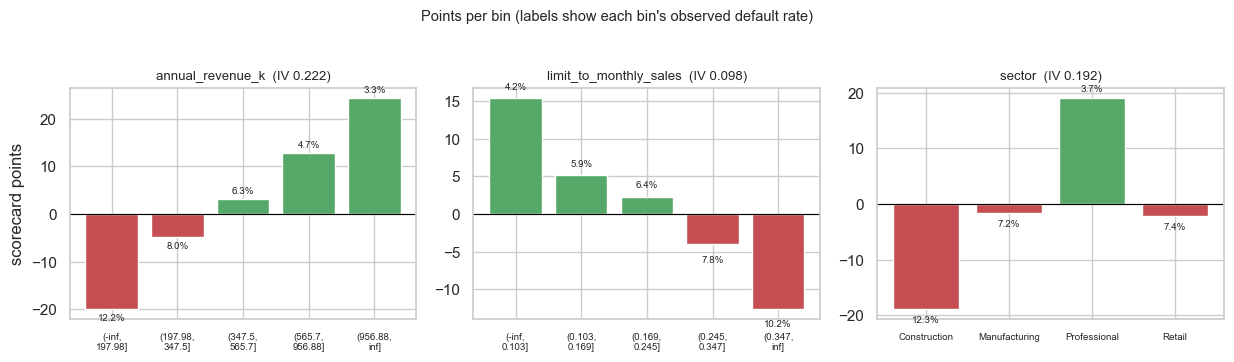

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))
for ax, c in zip(axes, ["annual_revenue_k", "limit_to_monthly_sales", "sector"]):
    t = spec[c][1]
    labels = [str(i) for i in t.index]
    pts = -coefs[c] * t["woe"] * factor
    bars = ax.bar(range(len(t)), pts, color=["#c44e52" if v < 0 else "#55a868" for v in pts])
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([l.replace(", ", ",\n") for l in labels], fontsize=7, rotation=0)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{c}  (IV {iv[c]:.3f})", fontsize=9.5)
    for i, (v, br) in enumerate(zip(pts, t["bad_rate"])):
        ax.text(i, v + (1.2 if v >= 0 else -2.4), f"{br:.1%}", ha="center", fontsize=7)
axes[0].set_ylabel("scorecard points")
plt.suptitle("Points per bin (labels show each bin's observed default rate)",
             fontsize=10.5, y=1.03)
plt.tight_layout(); plt.show()

Every feature is **monotone** — points rise steadily with size, fall steadily with the exposure ratio — which is what a credit committee looks for first. A non-monotone band ("companies trading 3–5 years are riskier than both younger and older ones") is sometimes real and more often a small-sample artefact, and the standard response is to merge bins until monotonicity holds rather than to defend the wiggle.

The spread is the story: `annual_revenue_k` runs from **−19.9 to +24.3** points, a 44-point range — more than two doublings of the odds. `sector` alone separates Construction (−18.8) from Professional (+19.0). And `limit_to_monthly_sales`, the variable the bureau score cannot see, contributes a 28-point range. That last one is where the model beats the legacy rulebook.

---

### ✋ Quick exercise (~2 min) — WOE and IV by hand

Compute the WOE and IV contribution for a single two-bin split, without the helper. Among **Construction** applicants in `train` there are some number of goods and bads; same for everyone else. Work out Construction's WOE and the IV of that 2-bin split.

Use `good_share = goods_in_bin / total_goods` and `bad_share = bads_in_bin / total_bads`, then `woe = ln(good_share / bad_share)` and `iv = Σ (good_share − bad_share) · woe`.

```python
is_con = train.sector == "Construction"
```

In [12]:
# ✍️ Your turn 👇
is_con = train.sector == "Construction"
# goods/bads in each of the two bins, then WOE for Construction and the split's IV:

<details>
<summary>✅ <b>Solution</b></summary>

```python
is_con = train.sector == "Construction"
bad = train.default.to_numpy() == 1
tot_good, tot_bad = (~bad).sum(), bad.sum()

for name, m in [("Construction", is_con.to_numpy()), ("everyone else", ~is_con.to_numpy())]:
    g, b = (m & ~bad).sum(), (m & bad).sum()
    gs, bs = g / tot_good, b / tot_bad
    woe = np.log(gs / bs)
    print(f"{name:15s} n={m.sum():>4d} goods={g:>4d} bads={b:>3d} "
          f"bad_rate={b / m.sum():>6.2%} good_share={gs:.3f} bad_share={bs:.3f} "
          f"WOE={woe:+.3f} IV_part={(gs - bs) * woe:+.4f}")

iv_split = sum(
    ((m & ~bad).sum() / tot_good - (m & bad).sum() / tot_bad)
    * np.log(((m & ~bad).sum() / tot_good) / ((m & bad).sum() / tot_bad))
    for m in [is_con.to_numpy(), ~is_con.to_numpy()])
print(f"\nIV of the 2-bin Construction split: {iv_split:.4f}  "
      f"(full 4-sector IV: {iv['sector']:.3f})")
```

Construction gets a clearly negative WOE — it holds a smaller share of the goods than of the bads. Note what WOE compares: **not** the bad rate against the overall bad rate, but the bin's share of goods against its share of bads. That is why WOE is insensitive to the overall default rate and travels well between populations with different base rates — a genuinely useful property when you re-develop a scorecard on a book whose mix has shifted.

The 2-bin IV is lower than the full 4-sector IV: collapsing Retail, Manufacturing and Professional into "everyone else" throws away the separation among them. More bins capture more information, up to the point where each bin is too small to estimate — which is exactly the bias–variance trade-off from NB 18, wearing a different hat.
</details>

## 3. Ranking is not enough — the level has to be right

Every decision so far in this module needed only a good *ranking*: NB 24's alert queue takes the top *k*, NB 23's campaign takes the top *n* by expected value. Credit is different. The cutoff `PD*` is an **absolute** number in probability units, and comparing a predicted PD against 15.6 % is meaningless unless the prediction means what it says.

This is NB 18's calibration lesson with money attached — and A1 made the same point about the difference between ranking decisions and threshold decisions.

In [13]:
print(f"mean predicted PD {p_test.mean():>7.2%}")
print(f"actual default rate {test.default.mean():>6.2%}")
print(f"ratio {p_test.mean() / test.default.mean():.3f}\n")

dec = pd.qcut(p_test, 10, labels=False, duplicates="drop")
cal = (pd.DataFrame({"decile": dec, "pred": p_test, "actual": test.default.to_numpy()})
       .groupby("decile").agg(n=("pred", "size"), mean_pred=("pred", "mean"),
                              actual=("actual", "mean")))
cal["ratio"] = cal.actual / cal.mean_pred
print(cal.to_string(formatters={"mean_pred": "{:.2%}".format, "actual": "{:.2%}".format,
                                "ratio": "{:.2f}".format}))

mean predicted PD   6.82%
actual default rate  6.95%
ratio 0.981

          n mean_pred actual ratio
decile                            
0       137     1.41%  0.73%  0.52
1       137     2.28%  4.38%  1.92
2       142     3.05%  2.82%  0.92
3       131     3.89%  5.34%  1.37
4       136     4.74%  5.88%  1.24
5       140     5.92%  4.29%  0.72
6       133     7.26%  9.02%  1.24
7       138     9.17%  7.25%  0.79
8       138    11.83%  9.42%  0.80
9       134    18.94% 20.90%  1.10


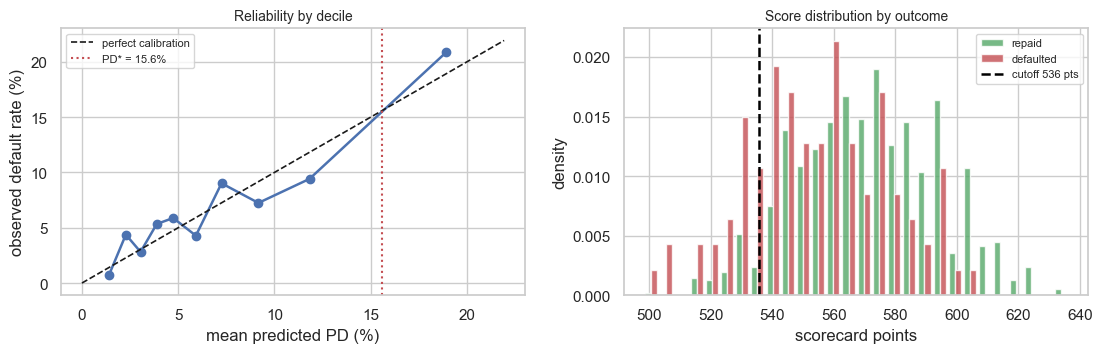

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.7))
axes[0].plot(cal.mean_pred * 100, cal.actual * 100, "o-", lw=1.8, color="#4c72b0")
lim = [0, max(cal.actual.max(), cal.mean_pred.max()) * 105]
axes[0].plot(lim, lim, "k--", lw=1.2, label="perfect calibration")
axes[0].axvline(PD_STAR * 100, color="#c44e52", ls=":", lw=1.5,
                label=f"PD* = {PD_STAR:.1%}")
axes[0].set_xlabel("mean predicted PD (%)"); axes[0].set_ylabel("observed default rate (%)")
axes[0].set_title("Reliability by decile", fontsize=10); axes[0].legend(fontsize=8)

good = score_test[test.default.to_numpy() == 0]
bad_s = score_test[test.default.to_numpy() == 1]
axes[1].hist([good, bad_s], bins=28, density=True, stacked=False,
             color=["#55a868", "#c44e52"], label=["repaid", "defaulted"], alpha=0.8)
cut_score = offset + factor * np.log((1 - PD_STAR) / PD_STAR)
axes[1].axvline(cut_score, color="black", lw=1.8, ls="--",
                label=f"cutoff {cut_score:.0f} pts")
axes[1].set_xlabel("scorecard points"); axes[1].set_ylabel("density")
axes[1].set_title("Score distribution by outcome", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The scorecard is **well calibrated in aggregate out of the box** — mean predicted 6.82 % against an actual 6.95 %. That is not luck: a logistic regression fitted by maximum likelihood on WOE features is calibrated on its training distribution almost by construction, which is another quiet argument for the old-fashioned approach.

The per-decile ratios bounce around (0.52 to 1.92), and that is **noise, not miscalibration** — each decile holds ~137 accounts and as few as one default, so the observed rate is wildly imprecise. Read the deciles that matter instead: the top one, where the cutoff lives, comes in at **18.94 % predicted against 20.90 % observed**, and the aggregate is within 2 %. If you want a decile table you can actually read, you need either a much larger test set or a bootstrap band around each point — quoting a 0.52 ratio on 137 accounts as evidence of anything is the same error as A2's subgroup analysis. A gradient-boosted model or an SVM would typically need a Platt or isotonic step on a held-out slice before its numbers could be compared to 15.6 % (NB 18 §7).

The right-hand panel shows the uncomfortable reality of credit scoring: the two distributions **overlap heavily**. A Gini of 0.39 is a perfectly respectable application scorecard, and it still means plenty of defaulters score above any cutoff you choose. The job is not to separate the populations — that is impossible — it is to put the cutoff where the *economics* say, and §4 is where we do that.

## 4. The decision: expected loss and the profit-optimal cutoff

**Expected loss** is the industry's standard decomposition:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

Approve an applicant with limit *L* when the expected margin beats the expected loss over a credit cycle:

$$(1 - \text{PD}) \cdot m \cdot L \;>\; \text{PD} \cdot \text{LGD} \cdot L$$

The limit *L* cancels. Rearranged:

$$\boxed{\text{PD}^{*} = \frac{m}{m + \text{LGD}} = \frac{0.12}{0.12 + 0.65} = 15.6\,\%}$$

Three things worth noticing about that box.

- **The approve/decline decision is limit-independent.** Whether to lend at all depends only on the *rate* of return and the *rate* of loss. How much to lend is a separate question — §5.
- **It is the same shape as every other decision in this module.** NB 23's `p* = cost/(s·CLV)`, NB 24's queue capacity, NB 26's critical ratio, A1's `|ε|·CM < 1`. A model output becomes an action through a ratio of costs, every time.
- **It is conservative**, because it prices one 30-day cycle against the whole exposure. A customer who stays five years earns that margin sixty times. Stretch A redoes the cutoff with a lifetime value and the answer moves a lot.

In [15]:
# Out-of-fold predictions over the WHOLE book -- more rows, less sampling noise
# than a single 30 % test slice, and still honest (each row scored by a model
# that never saw it).
p_oof = cross_val_predict(LogisticRegression(max_iter=2000),
                          woe_transform(book, spec), book.default,
                          cv=5, method="predict_proba")[:, 1]
limit = book.requested_limit.to_numpy()
bad_y = book.default.to_numpy()

def book_profit(mask):
    return (MARGIN * limit[mask] * (1 - bad_y[mask])).sum() - \
           (LGD * limit[mask] * bad_y[mask]).sum()

print(f"{'cutoff':>8} {'approve':>9} {'bad rate':>9} {'margin':>13} {'losses':>13} {'profit':>13}")
curve = []
for cut in [0.02, 0.04, 0.06, 0.08, 0.10, 0.13, PD_STAR, 0.18, 0.22, 0.30, 1.01]:
    ok = p_oof <= cut
    m = (MARGIN * limit[ok] * (1 - bad_y[ok])).sum()
    l = (LGD * limit[ok] * bad_y[ok]).sum()
    curve.append((cut, ok.mean(), bad_y[ok].mean(), m - l))
    print(f"{cut:>8.4f} {ok.mean():>9.1%} {bad_y[ok].mean():>9.2%} {m:>13,.0f} "
          f"{l:>13,.0f} {m - l:>13,.0f}")

  cutoff   approve  bad rate        margin        losses        profit
  0.0200     10.3%     2.35%     1,077,067       109,382       967,685
  0.0400     35.5%     3.22%     3,158,142       517,862     2,640,280
  0.0600     54.4%     3.35%     4,641,967       768,450     3,873,518
  0.0800     68.8%     4.09%     5,489,208     1,162,454     4,326,754
  0.1000     78.2%     4.55%     5,968,933     1,398,364     4,570,569
  0.1300     88.1%     5.19%     6,391,322     1,585,129     4,806,193
  0.1558     93.1%     5.71%     6,568,664     1,766,570     4,802,094
  0.1800     95.1%     6.07%     6,616,595     1,821,937     4,794,658
  0.2200     97.9%     6.35%     6,702,395     1,907,756     4,794,638
  0.3000     99.8%     6.85%     6,736,115     2,023,658     4,712,457
  1.0100    100.0%     6.92%     6,738,617     2,032,641     4,705,976


In [16]:
peak = max(c[3] for c in curve)
band = [c[0] for c in curve if c[3] >= 0.99 * peak]
print(f"peak profit on this grid {peak:,.0f} at cutoff {[c[0] for c in curve if c[3] == peak][0]:.4f}")
print(f"within 1 % of peak for cutoffs {min(band):.4f} to {max(band):.4f}")
print(f"the formula's answer, PD* = {PD_STAR:.4f}, sits inside that band")
print(f"\nat PD*: decline {(p_oof > PD_STAR).mean():.1%} of the applications "
      f"the legacy rule approved")

peak profit on this grid 4,806,193 at cutoff 0.1300
within 1 % of peak for cutoffs 0.1300 to 0.2200
the formula's answer, PD* = 0.1558, sits inside that band

at PD*: decline 6.9% of the applications the legacy rule approved


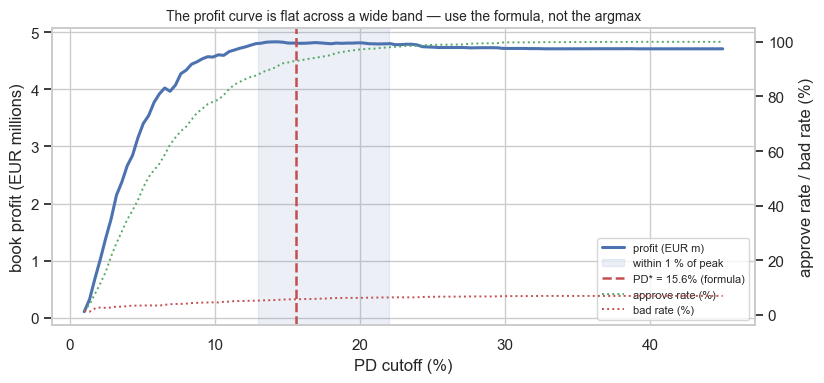

In [17]:
cuts = np.linspace(0.01, 0.45, 120)
prof = np.array([book_profit(p_oof <= c) for c in cuts])
appr = np.array([(p_oof <= c).mean() for c in cuts])
badr = np.array([bad_y[p_oof <= c].mean() if (p_oof <= c).any() else np.nan for c in cuts])

fig, ax = plt.subplots(figsize=(8.4, 4))
ax.plot(cuts * 100, prof / 1e6, lw=2.2, color="#4c72b0", label="profit (EUR m)")
ax.axvspan(min(band) * 100, max(band) * 100, color="#4c72b0", alpha=0.10,
           label="within 1 % of peak")
ax.axvline(PD_STAR * 100, color="#c44e52", lw=1.8, ls="--",
           label=f"PD* = {PD_STAR:.1%} (formula)")
ax.set_xlabel("PD cutoff (%)"); ax.set_ylabel("book profit (EUR millions)")
ax2 = ax.twinx()
ax2.plot(cuts * 100, appr * 100, lw=1.4, color="#55a868", ls=":", label="approve rate (%)")
ax2.plot(cuts * 100, badr * 100, lw=1.4, color="#c44e52", ls=":", label="bad rate (%)")
ax2.set_ylabel("approve rate / bad rate (%)"); ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower right")
ax.set_title("The profit curve is flat across a wide band — use the formula, not the argmax",
             fontsize=10)
plt.tight_layout(); plt.show()

> ⚠️ **Do not report the argmax.** The grid's best cutoff is 0.13 and the formula says 0.156, but **every cutoff between 0.13 and 0.22 is within 1 % of peak profit** — the curve has a plateau, and on a finite sample the argmax lands anywhere inside it, moving with the seed. This is A1's Guardrail 3 again: profit is flat near its optimum, so a sample-specific argmax is noise dressed as precision.
>
> The formula's answer is the one to ship, for a reason that has nothing to do with which number is bigger: **`PD* = m/(m + LGD)` does not depend on this sample at all.** It is derived from costs. When the margin changes next quarter, it moves for a reason you can explain to a committee, rather than because a different 30 % of the book landed in the test split.

The curve's shape is also the argument you make to the finance director who wanted to "tighten the rules." Tightening moves you **left**, and to the left of the plateau profit falls away fast — at a 4 % cutoff you approve a third of the book and keep barely half the profit (€2.64 m against €4.81 m). The bad rate does drop, which is exactly why bad rate is a dangerous thing to manage: **you can always cut losses to zero by lending to nobody.**

---

### ✋ Quick exercise (~2 min) — the cutoff for a different product

The webshop wants to extend Invoice 30 to its **IT hardware** category, where the contribution margin is thinner (**7 %**) but recovery is better because the kit can be repossessed (**LGD 45 %**).

Compute the new `PD*`. Is it higher or lower than 15.6 %, and does that match your intuition? Then compute the cutoff for a **services** line at 40 % margin and 90 % LGD.

```python
scenarios = [("Invoice 30 (supplies)", 0.12, 0.65),
             ("IT hardware", 0.07, 0.45),
             ("Services", 0.40, 0.90)]
```

In [18]:
# ✍️ Your turn 👇
scenarios = [("Invoice 30 (supplies)", 0.12, 0.65),
             ("IT hardware", 0.07, 0.45),
             ("Services", 0.40, 0.90)]
# PD* for each, plus the "good cycles per default" ratio LGD/margin:

<details>
<summary>✅ <b>Solution</b></summary>

```python
scenarios = [("Invoice 30 (supplies)", 0.12, 0.65),
             ("IT hardware", 0.07, 0.45),
             ("Services", 0.40, 0.90)]
print(f"{'product':>24} {'margin':>7} {'LGD':>6} {'PD*':>8} {'cycles per default':>20}")
for name, m, lgd in scenarios:
    print(f"{name:>24} {m:>7.0%} {lgd:>6.0%} {m / (m + lgd):>8.1%} {lgd / m:>19.1f}")
```

IT hardware comes out at **13.5 %** — *lower* than supplies, i.e. stricter. That may be counter-intuitive: recovery is much better, so surely you can afford more risk? But the margin fell by nearly half while LGD fell by only a third, so the *ratio* moved against you: hardware needs 6.4 good cycles to pay for a default against supplies' 5.4.

Services, at 40 % margin, tolerates a **30.8 %** default rate even with 90 % LGD — you can afford to lend to businesses you would never sell hardware to on credit. This is why the same customer is legitimately approved for one product and declined for another, and why "the credit cutoff" is not a company-level constant. It is per-product, and it moves whenever pricing does — which makes it something a pricing change (A1!) can silently break if nobody reruns the number.
</details>

## 5. How much? Credit limits as a risk-appetite overlay

The approve decision was limit-independent, which leaves an awkward gap: if every approved euro of exposure has positive expected value, the model's advice on limits is *"grant as much as they will take."*

That is technically what the expected-value maths says, and no lender does it, for reasons the single-cycle model does not contain: concentration risk (one large default can swamp a quarter), correlated defaults in a downturn (PDs move together, so the portfolio's loss distribution has a fat tail the independent sum ignores), and the simple fact that PD estimates are least reliable at the extremes.

So limits are a **policy overlay** — and the honest thing is to state what the overlay costs.

In [19]:
BANDS = [(0.02, 1.00), (0.05, 0.80), (0.10, 0.50), (PD_STAR, 0.25), (1.01, 0.00)]

def banded_multiple(p):
    out = np.zeros_like(p)
    prev = -1.0
    for hi, mult in BANDS:
        out[(p > prev) & (p <= hi)] = mult
        prev = hi
    return out

print("risk bands (share of the requested limit granted):")
prev = 0.0
for hi, mult in BANDS:
    n = ((p_oof > prev) & (p_oof <= hi)).sum()
    print(f"  PD {prev:>6.1%} - {hi if hi <= 1 else 1.0:>6.1%}  grant {mult:>4.0%}  "
          f"({n:>4d} applicants)")
    prev = hi

print(f"\n{'policy':>26} {'exposure':>14} {'profit':>13} {'expected loss':>15} {'EL/exposure':>12}")
for name, granted in [("requested in full", np.ones_like(p_oof)),
                      ("PD* cutoff, full limits", (p_oof <= PD_STAR).astype(float)),
                      ("risk-banded limits", banded_multiple(p_oof))]:
    g = limit * granted
    profit = (MARGIN * g * (1 - bad_y)).sum() - (LGD * g * bad_y).sum()
    el = (LGD * g * book.pd_true.to_numpy()).sum()
    print(f"{name:>26} {g.sum():>14,.0f} {profit:>13,.0f} {el:>15,.0f} "
          f"{el / g.sum():>12.2%}")

risk bands (share of the requested limit granted):
  PD   0.0% -   2.0%  grant 100%  ( 468 applicants)
  PD   2.0% -   5.0%  grant  80%  (1606 applicants)
  PD   5.0% -  10.0%  grant  50%  (1487 applicants)
  PD  10.0% -  15.6%  grant  25%  ( 675 applicants)
  PD  15.6% - 100.0%  grant   0%  ( 315 applicants)

                    policy       exposure        profit   expected loss  EL/exposure
         requested in full     59,282,280     4,705,976       1,973,621        3.33%
   PD* cutoff, full limits     57,456,670     4,802,094       1,753,817        3.05%
        risk-banded limits     39,474,240     3,536,361         977,043        2.48%


Read that table as a menu, not a ranking.

**Risk-banded limits cut expected loss from 3.33 % to 2.48 % of exposure — and cost about a quarter of the profit.** That is not the overlay failing; that is what buying insurance looks like. You are trading expected return for a tighter loss distribution, and whether that is worth it depends on things outside this notebook: how much capital stands behind the book, how a bad quarter would be received, whether the business could fund the working capital for €59 m of exposure at all.

What the analysis owes the decision-maker is the exchange rate — *"each percentage point of expected loss you want removed costs roughly €X of annual profit"* — not a recommendation dressed up as an optimum. Note also that the middle row is the honest comparator: applying the PD* cutoff at full limits earns the most, because it declines the worst applicants outright instead of lending them a quarter of what they asked for.

> 🧮 **A limit rule worth knowing.** Beyond risk banding, real policies cap exposure at a multiple of the customer's own trading volume — here `limit_to_monthly_sales`, capped around 0.5. The logic is not statistical but structural: a business that owes you more than it sells in a month has no plausible route to paying you from operations. Our own scorecard rediscovered this, giving the top exposure-ratio band −12.6 points.

---

### ✋ Quick exercise (~2 min) — size a limit from a loss budget

A customer scores a **PD of 8 %** and asks for a **€40,000** line. The credit policy says no single account may carry more than **€1,500** of expected loss.

What limit does that budget allow? What does that limit earn per 30-day cycle, and what would the full €40,000 request have earned? (Use `LGD` and `MARGIN` from §1.)

```python
pd_cust, requested, el_budget = 0.08, 40_000, 1_500
```

In [20]:
# ✍️ Your turn 👇
pd_cust, requested, el_budget = 0.08, 40_000, 1_500
# EL = PD * LGD * L. Invert for L, cap at the request, then price both options:

<details>
<summary>✅ <b>Solution</b></summary>

```python
pd_cust, requested, el_budget = 0.08, 40_000, 1_500
max_limit = el_budget / (pd_cust * LGD)
granted = min(requested, max_limit)
print(f"EL budget {el_budget:,.0f} EUR / (PD {pd_cust:.0%} x LGD {LGD:.0%}) "
      f"-> max limit {max_limit:>10,.0f} EUR")
print(f"granted = min(request, cap)              = {granted:>10,.0f} EUR "
      f"({granted / requested:.0%} of the request)")
for name, L in [("granted", granted), ("full request", requested)]:
    print(f"  {name:>13}: margin/cycle {MARGIN * L:>9,.0f} | "
          f"expected loss {pd_cust * LGD * L:>9,.0f} | "
          f"net EV/cycle {(1 - pd_cust) * MARGIN * L - pd_cust * LGD * L:>9,.0f}")
print(f"\nthis customer's PD ({pd_cust:.0%}) is below PD* ({PD_STAR:.1%}), so every "
      f"euro lent to them has positive expected value")
```

The budget allows **€28,846**, about 72 % of the request. Note what the arithmetic does *not* say: the customer's PD of 8 % is well under the 15.6 % cutoff, so the **full** €40,000 has positive expected value per cycle too — the EV-maximising limit is the whole request, and the €1,500 cap is pure risk appetite (§5's point, in one number).

The formula is worth internalising because it inverts cleanly: `L = EL_budget / (PD × LGD)`, so **limit is inversely proportional to PD**. Double the risk, halve the line. That single relation is the skeleton of most real limit policies, and it is why a risk-banded table like the one above is a reasonable approximation of it.

One trap: this prices *expected* loss on one account. A policy built only from per-account EL budgets can still concentrate — twenty accounts in the same sector at €1,500 EL each is €30,000 of correlated exposure, and correlation is exactly what expected loss cannot see (§7).
</details>

## 6. The selective-labels problem

Here is the hole in everything above.

The model was trained on the **approved book**, because that is the only place defaults are observed. But it is being asked to score **applications** — including the kind the legacy rule always declined. And the legacy rule did not decline at random: it screened on bureau score, trading history, the exposure ratio and director changes. So the training data has almost no examples of a high-exposure-ratio applicant, or one with two board changes, and the model has never seen what happens to them.

We saw the fingerprint in §2 (`director_changes`, IV 0.000, because the book only contains 0s and 1s). Now let's price it. Because this is a simulation we can do something no real lender can: build the model a lender *would* have built, and compare it against one trained on the labels of **every** applicant.

In [21]:
print("range of each feature -- the approved book vs the full applicant pool")
print(f"{'feature':>24} {'book':>18} {'pool':>18}")
for c in ["limit_to_monthly_sales", "director_changes", "payment_score", "months_trading"]:
    print(f"{c:>24} {f'{book[c].min():g} - {book[c].max():g}':>18} "
          f"{f'{apps[c].min():g} - {apps[c].max():g}':>18}")

range of each feature -- the approved book vs the full applicant pool
                 feature               book               pool
  limit_to_monthly_sales       0.029 - 0.55      0.029 - 1.101
        director_changes              0 - 1              0 - 4
           payment_score            62 - 92             5 - 92
          months_trading           18 - 265            2 - 265


In [22]:
# The model a real lender can build: trained on approvals only. (That's `card`.)
# The counterfactual: trained on the whole pool, labels and all.
full_train, _ = train_test_split(apps, test_size=0.3, random_state=0, stratify=apps.default)
spec_full = make_spec(full_train, KEEP)
card_full = LogisticRegression(max_iter=2000).fit(woe_transform(full_train, spec_full),
                                                 full_train.default)

p_book_model = card.predict_proba(woe_transform(apps, spec))[:, 1]
p_full_model = card_full.predict_proba(woe_transform(apps, spec_full))[:, 1]
declined = (~approved_mask).to_numpy()
pd_true = apps.pd_true.to_numpy()

print(f"AUC over the FULL applicant pool")
print(f"  trained on approvals only : {roc_auc_score(apps.default, p_book_model):.3f}")
print(f"  trained on everyone       : {roc_auc_score(apps.default, p_full_model):.3f}\n")
print(f"On the {declined.sum():,} DECLINED applications:")
print(f"  true mean PD                       {pd_true[declined].mean():>7.2%}")
print(f"  approvals-only model predicts      {p_book_model[declined].mean():>7.2%}  "
      f"({p_book_model[declined].mean() / pd_true[declined].mean():.2f}x the truth)")
print(f"  full-information model predicts    {p_full_model[declined].mean():>7.2%}  "
      f"({p_full_model[declined].mean() / pd_true[declined].mean():.2f}x)")

AUC over the FULL applicant pool
  trained on approvals only : 0.713
  trained on everyone       : 0.720

On the 1,449 DECLINED applications:
  true mean PD                        14.61%
  approvals-only model predicts       10.59%  (0.72x the truth)
  full-information model predicts     12.64%  (0.87x)


**The approvals-only model understates the risk of the applicants it has never seen by nearly 30 %** — it predicts 10.6 % where the truth is 14.6 %. And the direction is the dangerous one. This is not a random error: the model extrapolates its learned slopes into a region where the data ran out, and WOE binning makes that extrapolation especially flat, because an exposure ratio of 0.9 simply lands in the top *observed* bin (0.35+) and inherits its penalty. The bin that would have said "this is much worse" was never estimated, because the legacy policy never approved anyone who belonged in it.

So a model that looks excellent on the book will systematically **over-approve** exactly the applicants the old rule was protecting you from — and it will do so while reporting a good AUC on a test set drawn from the same censored population. Your validation cannot see the problem, because your validation data has the same hole in it.

In [23]:
lim_a = apps.requested_limit.to_numpy()
y_a = apps.default.to_numpy()

def policy(p, name, cut=PD_STAR):
    ok = p <= cut
    profit = (MARGIN * lim_a[ok] * (1 - y_a[ok])).sum() - (LGD * lim_a[ok] * y_a[ok]).sum()
    print(f"  {name:<28} approve {ok.mean():>6.1%}  bad {y_a[ok].mean():>6.2%}  "
          f"profit {profit:>13,.0f}")
    return profit

print("Applying the PD* cutoff to the whole applicant pool (2 years):")
p_legacy = policy(np.where(approved_mask, 0.0, 1.0), "legacy rulebook (today)")
p_appr = policy(p_book_model, "model, approvals-only")
p_full = policy(p_full_model, "model, full information")
p_oracle = policy(pd_true, "ORACLE (true PD)")
print(f"\n  model beats the legacy rulebook by {p_appr - p_legacy:>+13,.0f} EUR")
print(f"  cost of selective labels           {p_full - p_appr:>+13,.0f} EUR")
print(f"  remaining gap to the oracle        {p_oracle - p_full:>+13,.0f} EUR")

Applying the PD* cutoff to the whole applicant pool (2 years):
  legacy rulebook (today)      approve  75.8%  bad  6.92%  profit     4,705,976
  model, approvals-only        approve  89.8%  bad  7.13%  profit     5,751,312
  model, full information      approve  83.5%  bad  6.35%  profit     5,921,831
  ORACLE (true PD)             approve  85.2%  bad  5.83%  profit     6,262,341

  model beats the legacy rulebook by    +1,045,336 EUR
  cost of selective labels                +170,520 EUR
  remaining gap to the oracle             +340,509 EUR


Two findings, and the order matters.

**The model is a big win anyway: +€1.05 m over two years.** And look at *how* it wins — approvals rise from 75.8 % to 89.8 % while the bad rate barely moves (6.92 % → 7.13 %). It is not taking more risk for more volume; it is reallocating. It declines applicants the old rule liked (high exposure ratio with a good bureau score) and approves ones the old rule refused (young or small companies asking for modest lines in safe sectors). That "more approvals, same losses" result is the classic credit-model business case, and it is why these projects get funded.

**But selective labels leave €170k on the table**, and they take it from the most expensive place: the expansion decision. The full-information model approves *fewer* applications (83.5 % vs 89.8 %) at a lower bad rate (6.35 % vs 7.13 %) and earns more. The approvals-only model's confident expansion into unfamiliar territory is where the money goes.

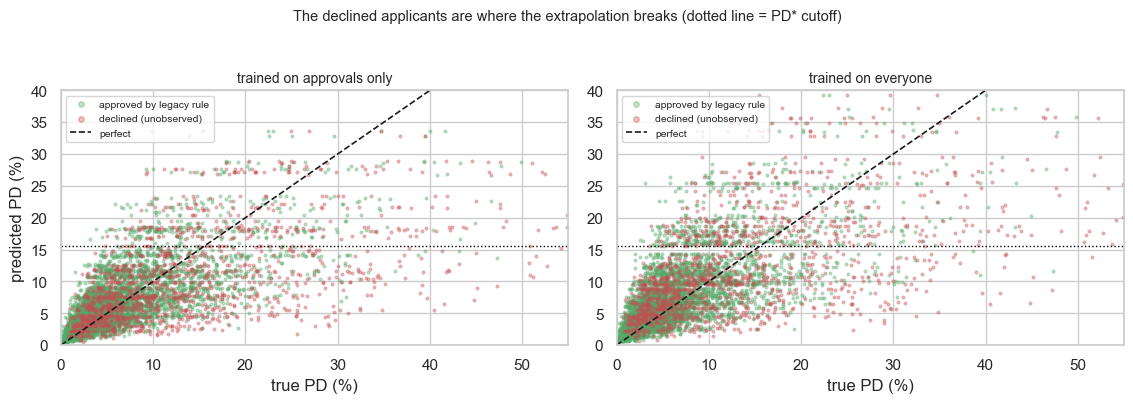

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
for ax, (p, name) in zip(axes, [(p_book_model, "trained on approvals only"),
                                (p_full_model, "trained on everyone")]):
    for m, c, lab in [(~declined, "#55a868", "approved by legacy rule"),
                      (declined, "#c44e52", "declined (unobserved)")]:
        ax.scatter(pd_true[m] * 100, p[m] * 100, s=4, alpha=0.35, color=c, label=lab)
    ax.plot([0, 60], [0, 60], "k--", lw=1.2, label="perfect")
    ax.axhline(PD_STAR * 100, color="black", lw=1.0, ls=":")
    ax.set_xlim(0, 55); ax.set_ylim(0, 40)
    ax.set_xlabel("true PD (%)"); ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7.5, loc="upper left", markerscale=2)
axes[0].set_ylabel("predicted PD (%)")
plt.suptitle("The declined applicants are where the extrapolation breaks "
             "(dotted line = PD* cutoff)", fontsize=10.5, y=1.03)
plt.tight_layout(); plt.show()

The left panel is the picture worth remembering. Green points — the approved book, the data the model learned from — hug the diagonal. Red points, the declined applicants, fall **below** it: their true PD runs out to 50 % while the model's predictions flatten out and stop around 25 %. Anything below the dotted line gets approved, so the whole red cloud that has drifted under it is a set of decisions the model is getting wrong with confidence.

In the right panel, trained on labels for everyone, the red cloud sits on the diagonal too.

### The fix a real lender can actually implement

You cannot get the right panel. What you can do:

1. **Reject inference** — impute outcomes for declined applications (parcelling, fuzzy augmentation, or fitting a model of the *approval* process). It is standard practice, it is better than nothing, and it cannot manufacture information that is not there; it mostly propagates your existing model's assumptions into the gap. Stretch B implements it.
2. **A randomized exploration budget** — deliberately approve a small random sample of applications you would have declined. This is the only method that generates genuinely new information, and it is what A2 was about: you are running an experiment to buy labels.
3. **Policy-boundary exploration** — spend the budget just below the cutoff rather than uniformly, where each label is most decision-relevant.

Let's price option 2.

In [25]:
base_profit = p_appr
print(f"{'explore':>9} {'mean n':>7} {'pool AUC':>10} {'declined-PD':>12} "
      f"{'profit gain':>14} {'(sd)':>10} {'explore cost':>14}")
for frac in (0.05, 0.10, 0.20):
    gains, costs, ratios, aucs, ns = [], [], [], [], []
    for s in range(20):
        r2 = np.random.default_rng(100 + s)
        expl = declined & (r2.random(len(apps)) < frac)
        labelled = apps[approved_mask.to_numpy() | expl]
        sp2 = make_spec(labelled, KEEP)
        m2 = LogisticRegression(max_iter=2000).fit(woe_transform(labelled, sp2),
                                                   labelled.default)
        p2 = m2.predict_proba(woe_transform(apps, sp2))[:, 1]
        ok = p2 <= PD_STAR
        gains.append(((MARGIN * lim_a[ok] * (1 - y_a[ok])).sum()
                      - (LGD * lim_a[ok] * y_a[ok]).sum()) - base_profit)
        costs.append((LGD * lim_a[expl] * y_a[expl]).sum()
                     - (MARGIN * lim_a[expl] * (1 - y_a[expl])).sum())
        ratios.append(p2[declined].mean() / pd_true[declined].mean())
        aucs.append(roc_auc_score(y_a, p2))
        ns.append(int(expl.sum()))
    print(f"{frac:>9.0%} {np.mean(ns):>7.0f} "
          f"{np.mean(aucs):>10.3f} {np.mean(ratios):>11.2f}x "
          f"{np.mean(gains):>+14,.0f} {np.std(gains):>10,.0f} {np.mean(costs):>+14,.0f}")

  explore  mean n   pool AUC  declined-PD    profit gain       (sd)   explore cost


       5%      71      0.715        0.74x         +3,544     38,316        -25,411


      10%     146      0.717        0.75x        +35,538     31,073        -47,782


      20%     290      0.719        0.78x        +43,604     14,981       -146,768


This is the section's most interesting result, and it is not the one I expected to write.

**Exploring is not a cost here — it is a profit.** The "explore cost" column is *negative* at every budget: the applications we randomly approved were, on average, worth approving. Of course they were — §1 told us 66 % of the declined pool has a true PD below the cutoff. When your legacy policy is badly miscalibrated, random exploration in the rejected region makes money **and** buys you the labels.

That will not always be true. If your policy is already near-optimal, exploration costs real money and has to be budgeted as the price of information. The general principle is the one A2 §7 arrived at from the other direction: **you are choosing between paying for information now and paying for ignorance forever.**

**The label value is real but slow.** A 20 % budget lifts profit by roughly €44k against the €170k selective-labels gap, and even that carries a standard deviation of €15k across draws — a single cohort of a few hundred extra labels does not fill a two-year hole. This is why real lenders run *permanent* small exploration streams rather than one-off studies: the value compounds as the sample accumulates, and the alternative is a policy that can never learn anything outside its own footprint.

> ⚠️ **Two honest caveats on that experiment.** Randomly approving applications you believe are bad has consequences for real businesses, and "we did it to improve the model" is a thin justification if the exposure is large — which is the argument for boundary exploration with small limits rather than uniform exploration at full limits. And our exploration is only unbiased because we randomised; approving the declined applicants a *human* felt good about would reproduce the original problem with extra steps.

---

### ✋ Quick exercise (~2 min) — who is in the swap set?

The model's real deliverable is a **swap set**: who gets swapped *out* of today's approvals and who gets swapped *in* from today's declines. Using `p_book_model` at the `PD_STAR` cutoff, count both groups and — because this is a simulation — report each group's *true* mean PD.

```python
swap_out = approved_mask.to_numpy() & (p_book_model > PD_STAR)
swap_in  = declined & (p_book_model <= PD_STAR)
```

In [26]:
# ✍️ Your turn 👇
swap_out = approved_mask.to_numpy() & (p_book_model > PD_STAR)
swap_in  = declined & (p_book_model <= PD_STAR)
# count each group, its share of today's decision, and its TRUE mean PD:

<details>
<summary>✅ <b>Solution</b></summary>

```python
swap_out = approved_mask.to_numpy() & (p_book_model > PD_STAR)
swap_in = declined & (p_book_model <= PD_STAR)
for name, m, base in [("swapped OUT (approve -> decline)", swap_out, approved_mask.to_numpy()),
                      ("swapped IN  (decline -> approve)", swap_in, declined)]:
    print(f"{name}: n={m.sum():>4d} ({m.sum() / base.sum():>5.1%} of that group) "
          f"true PD {pd_true[m].mean():>6.2%}  actual bad rate {y_a[m].mean():>6.2%}")
print(f"\nfor reference -- true PD: whole pool {pd_true.mean():.2%}, "
      f"cutoff {PD_STAR:.1%}")
print(f"exposure swapped out {lim_a[swap_out].sum():>12,.0f} EUR")
print(f"exposure swapped in  {lim_a[swap_in].sum():>12,.0f} EUR")
```

The **swapped-out** group is the model's clearest win: 314 accounts, 6.9 % of today's book, with a true mean PD of **19.0 %** and an actual bad rate of 23.9 % — well past the cutoff. These are the high-exposure-ratio and Construction accounts the bureau score flattered.

The **swapped-in** group is the one to argue about, and it is not a marginal slice: **1,148 applicants — 79 % of everyone the old rule declined**, carrying **€26.8 m** of new exposure against the €1.8 m removed. This is not a tweak to the policy, it is a different business. Their true mean PD is 11.6 % against a 15.6 % cutoff: below the bar, but not comfortably — and §6 has already told us the model *understates* declined-applicant risk by about 30 %, so the real margin of safety is thinner than the model thinks.

The swap set is also the right artefact politically. "Approve rate goes from 76 % to 90 %" invites an unwinnable argument about risk appetite; "here are 314 accounts we should stop lending to, and here is why, feature by feature" is a conversation a credit committee can actually have — and each row comes with reason codes straight off the scorecard (Practice 2). Lead with the swap-out list, stage the swap-in.
</details>

## 7. What real credit systems add (honest section)

- **LGD and EAD are models too.** We used two constants. Both are estimated in practice, both vary by product, security and collections capability, and both move in a downturn — at the same time PD does, which is the whole problem.
- **Point-in-time vs through-the-cycle PD.** Our PD is a 90-day, current-conditions estimate. Regulatory and provisioning frameworks (IFRS 9, CECL) want lifetime expected credit loss with macroeconomic scenarios and stage transfers. That is a different modelling exercise built on this one.
- **Correlated defaults.** Expected loss is a sum; the *distribution* of loss is not, because defaults correlate through the economy. Capital is held against the tail, and independent-PD sums say nothing about it. Vasicek-style single-factor models are the standard first step.
- **Behavioural scoring.** Application scoring is the cold start. Once a customer has been on the book for six months, their own payment behaviour dominates any application variable, and a behavioural scorecard replaces this one for limit increases and collections.
- **Fraud is not credit risk.** A first-payment default with fabricated details is NB 24's problem, not this notebook's: different features, different velocity, an adversary who adapts. Running them through one model does both jobs badly.
- **Vintage and roll-rate monitoring.** Scorecards decay. The standard instruments are vintage curves (default rate by months-on-book for each origination cohort), roll-rate matrices, and a population-stability index on the score bands. Stretch D builds the first.
- **Fairness, adverse action and the law.** Consumer lending is heavily regulated (ECOA/Reg B in the US, consumer-credit and equality law in the EU/UK); B2B trade credit is looser but not lawless, and reputational exposure does not care about the distinction. Two things always apply: you must be able to state **why** someone was declined, and you must not use protected characteristics — nor proxies that reconstruct them. Dropping the protected column is not a defence; `sector` and postcode can carry it. Stretch C audits this.
- **Collections is its own optimisation.** Every account past due is a sequence of decisions (when to call, when to settle, when to write off) with its own expected-value maths — closer to NB 23's campaign targeting than to anything here.

---

## 🧠 The story in one screen

1. **The legacy rulebook was not stupid** — 6.92 % bad on approvals vs 15.11 % on declines — but it screened on a **bureau score blind to the drivers that matter**: how much credit the applicant wants relative to their sales, board churn, sector.
2. **The scorecard is the deliverable.** WOE bins → IV screen → logistic fit → **sign check** → points. The sign check dropped `payment_score` for **zero** AUC cost, and gradient boosting with every feature did not beat it (0.690 vs 0.694). Explainability was free.
3. **Calibration matters here in a way it didn't in NB 23/24**, because `PD*` is an absolute threshold. The WOE logistic was calibrated out of the box (6.82 % predicted vs 6.95 % actual).
4. **One formula makes the decision:** `PD* = m/(m + LGD) = 15.6 %`. It is limit-independent, it is the same cost-ratio move as every other decision in this module, and it is conservative because it prices one cycle against the whole exposure.
5. **Do not report the argmax.** Every cutoff from 0.13 to 0.22 is within 1 % of peak profit. Ship the formula, which doesn't move with the sample.
6. **Limits are a risk-appetite overlay, not an optimum** — banding cut expected loss from 3.33 % to 2.48 % of exposure and cost a quarter of the profit. Quote the exchange rate; let someone else choose.
7. **Selective labels are the deepest problem in lending.** Trained on approvals, the model understates declined applicants' risk by ~30 % (10.6 % predicted vs 14.6 % true) and over-approves precisely where it has no data. Worth **€170k** here — and a validation set drawn from the same censored book cannot detect it. A randomized exploration budget is the only real fix, and in a badly-calibrated policy it *pays for itself*.

> 🧭 **Mental model, one last time.** NB 23: `p · s · CLV`. NB 24: analyst capacity. NB 26: the critical ratio. A1: elasticity against contribution margin. A2: the interval against the cost of acting. Here: **margin against loss given default.** Same move, five costumes — and this notebook adds the sting in the tail, which is that in lending *your own past decisions wrote the training data*, so the model's biggest errors live exactly where you have never looked.

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ The points/PD round trip
Write `pd_from_score(score)` and `score_from_pd(pd)` using the notebook's `factor` and `offset`, verify they invert each other, and confirm the PDO property: **adding 20 points must exactly double the good:bad odds.** Then build the lookup table a credit officer would pin up — score bands in steps of 20 with their implied PD and approve/decline verdict.

In [27]:
# Starter
def pd_from_score(score):
    ...  # invert: score = offset + factor * ln((1-pd)/pd)

def score_from_pd(pd_):
    ...

# verify the round trip and the 20-points-doubles-the-odds property

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def pd_from_score(score):
    return 1 / (1 + np.exp((np.asarray(score, dtype=float) - offset) / factor))

def score_from_pd(pd_):
    pd_ = np.asarray(pd_, dtype=float)
    return offset + factor * np.log((1 - pd_) / pd_)

print(f"round trip: 580 -> {pd_from_score(580):.4%} -> {score_from_pd(pd_from_score(580)):.1f}")

for s in (540, 560, 580):
    o1 = (1 - pd_from_score(s)) / pd_from_score(s)
    o2 = (1 - pd_from_score(s + PDO)) / pd_from_score(s + PDO)
    print(f"odds at {s}: {o1:>7.2f}:1   at {s + PDO}: {o2:>7.2f}:1   ratio {o2 / o1:.3f}")

cut = score_from_pd(PD_STAR)
print(f"\ncutoff score = {cut:.0f} points\n")
print(f"{'band':>14} {'implied PD':>12}  decision")
for s in range(500, 661, 20):
    print(f"{f'{s}-{s + 19}':>14} {pd_from_score(s):>12.2%}  "
          f"{'APPROVE' if s >= cut else 'DECLINE'}")
```

The ratio comes out at exactly **2.000** at every score — that is the PDO convention doing its job, and it is why scorecards are quoted this way. "You are 40 points short" means "your odds of repaying are four times worse than our cutoff", which is a sentence a credit officer can hold in their head without a calculator.

The lookup table is the whole point of the exercise. Once the scorecard is expressed in points, the decision is a table on a wall; nothing about the model needs to be re-derived to use it, and an auditor can reproduce any decision by hand.
</details>

### Exercise 2 — ⭐⭐ Reason codes for a decline letter
A declined applicant is entitled to know why. Write `reason_codes(applicant, top_n=3)` that returns the bins costing this applicant the most points **relative to the best bin available on that feature** — the standard "points below best" method. Run it on the three highest-exposure declined applicants and draft the sentence you would actually send.

In [28]:
# Starter
def reason_codes(applicant, top_n=3):
    ...  # for each feature: points at the applicant's bin vs the max points on
    ...  # that feature; the biggest shortfalls are the reasons

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def points_table(col):
    t = spec[col][1]
    return -coefs[col] * t["woe"] * factor, t

def reason_codes(applicant, top_n=3):
    out = []
    for c in KEEP:
        pts, t = points_table(c)
        if spec[c][0] is not None:
            b = pd.cut([applicant[c]], spec[c][0])[0]
        else:
            b = applicant[c]
        got = float(pts.loc[b]) if b in pts.index else 0.0
        out.append({"feature": c, "value": applicant[c], "bin": str(b),
                    "points": got, "best_possible": float(pts.max()),
                    "shortfall": float(pts.max()) - got})
    return (pd.DataFrame(out).sort_values("shortfall", ascending=False)
            .head(top_n).reset_index(drop=True))

# the applicants the MODEL declines, largest exposure first
model_declines = apps[p_book_model > PD_STAR]
worst = model_declines.nlargest(3, "requested_limit")
cut_pts = score_from_pd(PD_STAR)
for _, a in worst.iterrows():
    p_a = card.predict_proba(woe_transform(a.to_frame().T, spec))[:, 1][0]
    s_a = score_from_pd(p_a)
    print(f"\n=== applicant: {a.sector}, {a.months_trading} months trading, "
          f"revenue {a.annual_revenue_k:,.0f}k, requested {a.requested_limit:,.0f} EUR")
    print(f"    score {s_a:.0f} pts | PD {p_a:.2%} | cutoff {cut_pts:.0f} pts "
          f"-> {'APPROVE' if s_a >= cut_pts else 'DECLINE'} "
          f"({cut_pts - s_a:+.0f} points vs cutoff)")
    rc = reason_codes(a)
    print(rc.to_string(index=False, formatters={"points": "{:+.1f}".format,
          "best_possible": "{:+.1f}".format, "shortfall": "{:.1f}".format}))
```

*"We were unable to approve your Invoice 30 application. The main factors were: the credit line requested relative to your monthly sales; your industry sector; and the length of your trading history. You may reapply with a lower credit limit, or after a further six months of trading."*

Three properties make that sentence defensible. It is **specific** (named factors, in order of how much they cost). It is **actionable** — the exposure-ratio reason tells the applicant something they can change *today*, which is the single most useful thing a decline letter can do, and it is why "points below best" is preferred over just reporting the lowest-scoring bins. And it is **faithful**: the reasons come from the model that made the decision, not a post-hoc story, so it stays true when the scorecard is refitted.

The contrast with a gradient-boosted model is the practical argument for scorecards. You can generate SHAP values for a GBM, but you cannot generate a one-page table an auditor reproduces by hand, and you cannot promise the explanation is the mechanism rather than an approximation of it.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the scorecard that got better by cheating
A colleague adds `postcode_area` (80 areas) to the scorecard and reports test AUC jumping from 0.694 to **0.742** — "regional risk really matters." The postcode in the code below is **pure random noise**, generated independently of everything. Their code runs. Find the bug, and explain why the noise feature *helped*.

In [29]:
# A colleague's "improved" scorecard. postcode_area is RANDOM NOISE.
rz = np.random.default_rng(0)
book2 = book.copy()
book2["postcode_area"] = rz.integers(0, 80, len(book2))

# "Bin everything up front so the WOE tables are consistent, then split."
spec_bug = make_spec(book2, KEEP + ["postcode_area"])
X_all = woe_transform(book2, spec_bug)

tr2, te2 = train_test_split(book2, test_size=0.3, random_state=0, stratify=book2.default)
m_bug = LogisticRegression(max_iter=2000).fit(X_all.loc[tr2.index], tr2.default)
auc_bug = roc_auc_score(te2.default, m_bug.predict_proba(X_all.loc[te2.index])[:, 1])
print(f"'improved' scorecard test AUC: {auc_bug:.3f}")
print(f"postcode_area IV: {spec_bug['postcode_area'][1].iv.sum():.3f}  (looks 'strong'!)")

'improved' scorecard test AUC: 0.742
postcode_area IV: 0.209  (looks 'strong'!)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

**The bug is one line: `make_spec(book2, ...)` fits the WOE tables on the *whole* dataset, before the split.** WOE is a **supervised** transform — every bin's value is computed from the target. So each test row's `postcode_area_woe` was computed using, among others, *that row's own default flag*. The label leaked into the feature. This is NB 19's target-leakage lesson and the campaign taxonomy's "stats fitted pre-split", with a credit-specific disguise: it looks like data preparation, not like modelling.

Why the **noise** feature is where it shows up: with 80 areas and ~4,500 rows there are only ~56 rows per bin and ~4 defaults. Each bin's WOE is almost entirely noise — and it is noise **fitted to these exact rows' labels**, so it predicts them. Real features have real signal and don't need to cheat; the noise feature has nothing else to offer, so it takes the whole leak. That is the general pattern: **leakage surfaces first in your highest-cardinality, lowest-signal variables.**

```python
def auc_with(cols, fit_on):
    spx = make_spec(fit_on, cols)
    m = LogisticRegression(max_iter=2000).fit(woe_transform(tr2, spx), tr2.default)
    return roc_auc_score(te2.default, m.predict_proba(woe_transform(te2, spx))[:, 1])

print(f"WOE on TRAIN only, no postcode : {auc_with(KEEP, tr2):.3f}   <- the real model")
print(f"WOE on TRAIN only, + postcode  : {auc_with(KEEP + ['postcode_area'], tr2):.3f}   "
      f"<- noise HURTS, and you can see it")
print(f"WOE on ALL data,   + postcode  : {auc_with(KEEP + ['postcode_area'], book2):.3f}   "
      f"<- noise HELPS. ship it and nothing happens")
print(f"\npostcode IV fitted on train {make_spec(tr2, ['postcode_area'])['postcode_area'][1].iv.sum():.3f}"
      f" | on all data {make_spec(book2, ['postcode_area'])['postcode_area'][1].iv.sum():.3f}")
```

Fitted correctly, the noise feature **lowers** test AUC from 0.694 to about 0.651 — the honest signal that it is junk, and you would drop it. Fitted before the split it *raises* AUC to 0.742, so the colleague keeps it, ships it, and the production scorecard performs like the 0.651 version while the validation report promises 0.742.

Note the IV is high (>0.2) on either fit, so **IV cannot catch this**. The defences are structural: fit every supervised transform inside the training fold (a `Pipeline` or a custom transformer, per NB 19 §7), be suspicious of high IV on high-cardinality features, and treat "unexplained AUC jump from a plausible-sounding new variable" as a leak hypothesis until disproved.
</details>

### Exercise 4 — ⭐⭐ Bad rate is a trap
The finance director wants the approved-book bad rate down from 6.92 % to **4 %**. Find the cutoff that delivers it, then report what it costs: approve rate, profit, and profit per euro of exposure. Finally, find the cutoff that maximises *profit per euro of exposure* rather than total profit and explain why a capital-constrained lender might genuinely prefer it.

In [30]:
# Starter
# 1. search cutoffs for the one giving a 4% bad rate on the approved book
# 2. compare approve rate / profit / profit-per-exposure against the PD* cutoff
# 3. argmax of profit-per-exposure -- and why it differs

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
grid = np.linspace(0.01, 0.60, 300)
rows = []
for c in grid:
    ok = p_oof <= c
    if ok.sum() < 50:
        continue
    exp_ = limit[ok].sum()
    rows.append({"cutoff": c, "approve": ok.mean(), "bad": bad_y[ok].mean(),
                 "profit": book_profit(ok), "exposure": exp_,
                 "profit_per_eur": book_profit(ok) / exp_})
r = pd.DataFrame(rows)

target = r.iloc[(r.bad - 0.04).abs().argmin()]
at_star = r.iloc[(r.cutoff - PD_STAR).abs().argmin()]
best_eur = r.loc[r.profit_per_eur.idxmax()]
best_tot = r.loc[r.profit.idxmax()]

print(f"{'policy':>26} {'cutoff':>8} {'approve':>9} {'bad':>7} {'profit':>13} {'per EUR':>9}")
for name, row in [("4 % bad-rate target", target), ("PD* = 15.6 %", at_star),
                  ("max total profit", best_tot), ("max profit per EUR", best_eur)]:
    print(f"{name:>26} {row.cutoff:>8.3f} {row.approve:>9.1%} {row.bad:>7.2%} "
          f"{row.profit:>13,.0f} {row.profit_per_eur:>9.3f}")
print(f"\ncost of hitting the 4 % target: {target.profit - at_star.profit:>+,.0f} EUR "
      f"({target.profit / at_star.profit - 1:+.1%})")
```

Hitting 4 % costs about **€490k, a tenth of the profit**, because the only way to get there is to decline a lot of applicants whose expected value is comfortably positive. **Bad rate is an input to the decision, not an objective** — you can drive it to zero by lending to nobody, and any metric optimised by doing nothing is the wrong metric. The same trap appears as revenue-maximising pricing in A1 §4 and as queue size in NB 24 §5.

The last row is the honest counter-argument, though. Profit **per euro of exposure** is maximised at a much tighter cutoff, because the marginal approvals near PD* earn very little per euro tied up. If the binding constraint is capital or working capital rather than applicant supply — which for a webshop funding its own trade credit is entirely plausible — then per-euro return is the right objective and a stricter cutoff is correct. Same data, same model, different constraint, different answer. Which is the general lesson: get the constraint from the business before you optimise anything.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ The cutoff, with a lifetime instead of a cycle
§4's `PD*` prices **one 30-day cycle** of margin against the whole exposure — deliberately conservative. But a customer who survives keeps trading: NB 23's CLV logic applies directly. Recompute the cutoff using the expected *number* of profitable cycles before default (a geometric series in the monthly survival probability, capped at 36 months and discounted), and work out how many more applicants get approved and what it does to profit. Then find the flaw in being too clever about this.

In [31]:
# Starter — sketch:
# monthly survival = 1 - pd_monthly, where pd_monthly comes from the 90-day PD:
#   (1 - pd_m)**3 = 1 - pd_90   ->   pd_m = 1 - (1 - pd_90)**(1/3)      [NB 23 §2]
# expected cycles = sum_{t=1..36} (1-pd_m)**t / (1+r)**t
# approve iff  cycles * margin * L * (1 - pd_m)  >  pd_m * LGD * L

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def monthly_pd(pd_90):
    return 1 - (1 - np.asarray(pd_90, dtype=float)) ** (1 / 3)

def expected_cycles(pd_90, horizon=36, annual_rate=0.10):
    pm = monthly_pd(pd_90)
    r_m = (1 + annual_rate) ** (1 / 12) - 1
    t = np.arange(1, horizon + 1)
    surv = (1 - pm[:, None]) ** t
    disc = 1 / (1 + r_m) ** t
    return (surv * disc).sum(1)

pm = monthly_pd(p_oof)
cycles = expected_cycles(p_oof)
ev_lifetime = cycles * MARGIN * (1 - pm) - pm * LGD          # per EUR of limit
print(f"expected cycles: p10 {np.percentile(cycles, 10):.1f} | "
      f"median {np.median(cycles):.1f} | p90 {np.percentile(cycles, 90):.1f}")

# the implied cutoff: the 90-day PD at which lifetime EV crosses zero
grid = np.linspace(0.01, 0.95, 2000)
pmg = monthly_pd(grid)
evg = expected_cycles(grid) * MARGIN * (1 - pmg) - pmg * LGD
cut_life = grid[np.argmin(np.abs(evg))]
print(f"single-cycle cutoff {PD_STAR:.1%}  ->  lifetime cutoff {cut_life:.1%}")

for name, ok in [("single-cycle PD*", p_oof <= PD_STAR),
                 ("lifetime EV > 0", ev_lifetime > 0)]:
    print(f"  {name:>18} approve {ok.mean():>6.1%} bad {bad_y[ok].mean():>6.2%} "
          f"profit(1 cycle) {book_profit(ok):>13,.0f}")
```

The lifetime cutoff comes out at **65.4 %** against the single-cycle **15.6 %** — wildly more permissive. The median applicant has ~23 discounted profitable cycles ahead of them, so survivors pay the margin many times over while the loss happens at most once. On this book **everyone** clears the bar, and the decision degenerates into "approve, and manage the limit."

**And that is the flaw.** Three assumptions are doing all the work, and all three are the ones NB 23 flagged for CLV: a **constant hazard** (real default risk is front-loaded — the first six months are the dangerous ones, so the geometric series overstates survival), an exposure that stays at the limit for 36 months while you earn margin on it, and no competitive or behavioural change. Stack them and a lifetime cutoff will happily approve a book that defaults in year one.

The practical resolution is the one real lenders use: **decide with the short-horizon cutoff, then grow the relationship behaviourally.** Approve on a conservative single-cycle rule with a small limit, then raise the limit on observed repayment (a behavioural scorecard, §7). That captures most of the lifetime value while keeping the exposure small exactly when your uncertainty is largest — and it does not require you to be right about a 36-month survival curve you have no data for.
</details>

### Stretch exercise B — ⭐⭐⭐ Reject inference, and its limits
Implement **fuzzy augmentation** reject inference: score the declined applications with the approvals-only model, then add each declined applicant to the training set **twice** — once as a "good" with weight `1 − p̂` and once as a "bad" with weight `p̂` — and refit with `sample_weight`. Compare against the approvals-only baseline, the full-information model, and §6's randomized-exploration result. Then explain the result you get, which is probably not the one the technique's reputation suggests.

In [32]:
# Starter — sketch:
# 1. p_hat for declined applicants from the approvals-only model
# 2. build an augmented frame: approvals (weight 1) + declined-as-good (1 - p_hat)
#    + declined-as-bad (p_hat)
# 3. refit WOE + logistic with sample_weight, then evaluate on the FULL pool

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
dec_df = apps[declined].copy()
p_hat = card.predict_proba(woe_transform(dec_df, spec))[:, 1]

as_good = dec_df.copy(); as_good["default"] = 0; as_good["w"] = 1 - p_hat
as_bad = dec_df.copy();  as_bad["default"] = 1;  as_bad["w"] = p_hat
appr_df = apps[approved_mask].copy(); appr_df["w"] = 1.0
aug = pd.concat([appr_df, as_good, as_bad], ignore_index=True)

spec_aug = make_spec(aug, KEEP)                 # WOE now sees the declined region
X_aug = woe_transform(aug, spec_aug)
m_aug = LogisticRegression(max_iter=2000).fit(X_aug, aug.default,
                                              sample_weight=aug.w.to_numpy())
p_aug = m_aug.predict_proba(woe_transform(apps, spec_aug))[:, 1]

def summarise(name, p):
    ok = p <= PD_STAR
    profit = (MARGIN * lim_a[ok] * (1 - y_a[ok])).sum() - (LGD * lim_a[ok] * y_a[ok]).sum()
    print(f"  {name:<26} AUC {roc_auc_score(y_a, p):.3f} | declined-PD "
          f"{p[declined].mean() / pd_true[declined].mean():.2f}x | approve {ok.mean():>5.1%} "
          f"| profit {profit:>12,.0f}")

summarise("approvals-only", p_book_model)
summarise("+ fuzzy augmentation", p_aug)
summarise("full information", p_full_model)
summarise("ORACLE", pd_true)
```

**Fuzzy augmentation makes things worse on the metric that matters.** The declined-region calibration does improve a little (0.72× → 0.77× of the truth), but pool AUC *falls* from 0.713 to 0.698 and profit falls from €5.75 m to €5.63 m — it approves *more* applications (92.2 % vs 89.8 %) on the strength of labels it invented.

That is the correct and instructive result, and it follows from what the method actually does: it labels the declined applicants using **the very model whose blind spot you are trying to fix.** The imputed outcomes agree with the existing model by construction, so you have laundered an assumption into a dataset — and then handed the refit thousands of rows of model-generated pseudo-signal that dilute the genuinely observed ones. The confidence goes up; the information does not.

The one genuine benefit is visible in `spec_aug`: the **binning** now spans the declined region, so exposure ratios above 0.55 get their own bins instead of being lumped into the top observed band. That is a real improvement in the model's *functional form* — and it is what produced the calibration gain. But the bins' WOE values are still imputed, not observed, so the gain is structural, not informational.

The honest hierarchy on this data: **randomized exploration > nothing > fuzzy reject inference.** That ordering is stronger than the literature's, and you should not over-generalise from one simulation — reject inference is standard practice and often helps, particularly where the approval rule was closer to random than ours. But the mechanism that makes it *unable* to help is general: **no imputation scheme can create information about a region you have never observed.** Whatever it produces is your current model's beliefs, re-served as evidence. Use it for the binning, not for the confidence, and never let it stand in for an exploration budget — which, in a lot of credit shops, is exactly what it does.
</details>

### Stretch exercise C — ⭐⭐⭐ Proxy discrimination and the cost of a fairness constraint
Suppose the webshop's applicants carry an attribute you may **not** use — say a founder characteristic correlated with `sector` and `months_trading`. Simulate such an attribute, confirm the scorecard (which never sees it) still produces a materially different approval rate across its groups, and quantify the gap. Then implement one mitigation — equalising approval rates by using group-specific cutoffs, and separately by dropping the most-proxying feature — and report the profit cost of each. Which would you defend, and to whom?

In [33]:
# Starter — sketch:
# 1. group G ~ Bernoulli(p) with p depending on sector and months_trading
#    (so it is CORRELATED with legitimate risk factors, not causal)
# 2. approval rate and mean predicted PD by group under the PD* cutoff
# 3. mitigation A: group-specific cutoffs equalising approval rate
#    mitigation B: drop the highest-proxy feature, refit, re-measure
# 4. profit cost of each; and check whether the gap is 'explained' by true PD

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rg = np.random.default_rng(11)
lean = (0.55 * (apps.sector == "Construction").to_numpy()
        + 0.35 * (apps.months_trading < 36).to_numpy())
group = rg.random(len(apps)) < (0.25 + 0.5 * lean / lean.max())   # protected attribute

ok = p_book_model <= PD_STAR
print(f"{'group':>10} {'n':>6} {'approve':>9} {'mean pred PD':>14} {'mean TRUE PD':>14}")
for g, lab in [(group, "A"), (~group, "B")]:
    print(f"{lab:>10} {g.sum():>6d} {ok[g].mean():>9.1%} {p_book_model[g].mean():>14.2%} "
          f"{pd_true[g].mean():>14.2%}")
gap = ok[~group].mean() - ok[group].mean()
print(f"\napproval-rate gap: {gap:+.1%} (the model never saw `group`)")

# Mitigation A: group-specific cutoffs that equalise approval rates
target = ok.mean()
cut_a = np.quantile(p_book_model[group], target)
cut_b = np.quantile(p_book_model[~group], target)
ok_a = np.where(group, p_book_model <= cut_a, p_book_model <= cut_b)
# Mitigation B: drop the strongest proxy and refit
proxy = max(KEEP, key=lambda c: abs(np.corrcoef(
    woe_transform(apps, spec)[c + "_woe"], group.astype(float))[0, 1]))
KEEP_B = [c for c in KEEP if c != proxy]
card_b, spec_b = fit_scorecard(KEEP_B)
p_b = card_b.predict_proba(woe_transform(apps, spec_b))[:, 1]
ok_b = p_b <= PD_STAR

def prof(mask):
    return (MARGIN * lim_a[mask] * (1 - y_a[mask])).sum() - (LGD * lim_a[mask] * y_a[mask]).sum()

print(f"strongest proxy feature: {proxy}\n")
print(f"{'policy':>28} {'approve A':>10} {'approve B':>10} {'gap':>8} {'profit':>13}")
for name, m in [("PD* cutoff (unmitigated)", ok), ("A: group-specific cutoffs", ok_a),
                (f"B: drop {proxy}", ok_b)]:
    print(f"{name:>28} {m[group].mean():>10.1%} {m[~group].mean():>10.1%} "
          f"{m[~group].mean() - m[group].mean():>+8.1%} {prof(m):>13,.0f}")
```

**The scorecard never sees `group` and still approves group B at 91.6 % against group A's 86.5 % — a 5.1-point gap**, because `sector` (the strongest proxy here) and `months_trading` carry it. That is proxy discrimination, and it is why "we don't use protected attributes" is a statement about your code, not about your outcomes. Note too that part of the gap is *explained* by genuinely different true PD — which is exactly what makes this hard: some of the disparity reflects real risk and some reflects the model's blind spots, and the printout deliberately shows both predicted and true PD by group so you can see the difference.

The two mitigations answer different questions and cost very differently. **Group-specific cutoffs** close the gap almost completely (5.1 → 0.2 points) and cost essentially nothing in profit — here they even earn slightly more, because equalising rates happens to reallocate toward better applicants. But they require you to *use* the protected attribute in the decision, which in consumer lending is generally illegal and in any setting is hard to explain to whichever applicant was held to the stricter bar. **Dropping `sector`** keeps the decision attribute-blind, costs about **€75k** of profit, and only gets the gap to 1.2 points — because the remaining features re-encode it. That pattern is typical: the blind mitigation is the expensive one *and* the incomplete one.

There is no purely technical answer here, and pretending otherwise is the failure mode. What an analyst *can* do is refuse to let the choice be implicit: measure the disparity, decompose how much survives conditioning on legitimate risk, cost each mitigation, and put the trade-off in front of the people who are accountable for it — with legal counsel in the room. **"The model said so" is not a defence**, and neither is "we didn't include that column."
</details>

### Stretch exercise D — ⭐⭐⭐ Vintage curves and the scorecard that quietly expired
Scorecards decay. Simulate three origination cohorts ("vintages") in which the applicant mix drifts — later cohorts skew toward Construction and higher exposure ratios — score all of them with the scorecard fitted on the *first* cohort, and build the two instruments a credit-risk team actually monitors: a **vintage table** (bad rate by cohort at a fixed score band) and a **population stability index** on the score distribution. At what PSI would you trigger a redevelopment?

In [34]:
# Starter — sketch:
# 1. three cohorts: build_applications(seed=...) with a drifting sector mix / ratio
# 2. score all with the cohort-1 scorecard; bad rate per (cohort, score band)
# 3. PSI = sum over bands of (pct_new - pct_base) * ln(pct_new / pct_base)
#    rules of thumb: < 0.10 stable | 0.10-0.25 monitor | > 0.25 redevelop

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def pd_from_score(score):                      # self-contained (also Practice 1)
    return 1 / (1 + np.exp((np.asarray(score, dtype=float) - offset) / factor))

def drifted_cohort(seed, con_share, ratio_scale):
    """A later vintage: more Construction, larger requested limits."""
    rng = np.random.default_rng(seed)
    d = build_applications(seed=seed).copy()
    n = len(d)
    flip = rng.random(n) < con_share
    d.loc[flip, "sector"] = "Construction"
    d["limit_to_monthly_sales"] = (d.limit_to_monthly_sales * ratio_scale).clip(0.03, 1.6)
    d["requested_limit"] = (d.limit_to_monthly_sales * d.monthly_sales).round(-1)
    # recompute the truth under the drifted features
    visible = -0.010 * d.months_trading - 0.55 * np.log(d.annual_revenue_k / 420)
    hidden = (1.9 * d.limit_to_monthly_sales + 0.75 * d.director_changes
              + d.sector.map(SECTOR_RISK))
    lat = -2.95 + visible + hidden + rng.normal(0, 0.45, n)
    d["pd_true"] = 1 / (1 + np.exp(-lat))
    d["default"] = rng.binomial(1, d.pd_true)
    return d

vintages = {"2024-H1 (base)": book,
            "2024-H2": drifted_cohort(21, 0.10, 1.15),
            "2025-H1": drifted_cohort(22, 0.22, 1.35)}

BANDS_S = [-np.inf, 545, 565, 585, 605, np.inf]
base_pct = None
print(f"{'vintage':>16} {'n':>6} {'mean score':>11} {'bad rate':>10} {'PSI':>7}  verdict")
for name, d in vintages.items():
    p = card.predict_proba(woe_transform(d, spec))[:, 1]
    s = offset + factor * np.log((1 - p) / p)
    pct = np.histogram(s, bins=BANDS_S)[0] / len(s)
    if base_pct is None:
        base_pct, psi = pct, 0.0
    else:
        eps = 1e-6
        psi = float(((pct - base_pct) * np.log((pct + eps) / (base_pct + eps))).sum())
    verdict = ("stable" if psi < 0.10 else "monitor" if psi < 0.25 else "REDEVELOP")
    print(f"{name:>16} {len(d):>6d} {s.mean():>11.1f} {d.default.mean():>10.2%} "
          f"{psi:>7.3f}  {verdict}")

print("\nvintage table -- bad rate within a FIXED score band (585-605):")
for name, d in vintages.items():
    p = card.predict_proba(woe_transform(d, spec))[:, 1]
    s = offset + factor * np.log((1 - p) / p)
    m = (s >= 585) & (s < 605)
    print(f"  {name:>16} n={m.sum():>4d}  observed bad {d.default.to_numpy()[m].mean():>6.2%} "
          f"| scorecard implies {pd_from_score(595):>6.2%}"
          if m.sum() else f"  {name:>16} (empty band)")
```

Two different alarms, and they are not interchangeable.

**PSI** watches the *input* side: has the population moved? It climbs 0.000 → 0.079 → **0.184** as the mix drifts toward Construction and bigger asks, and the mean score falls 570 → 559. It needs **no outcome data**, so it fires months before any default is observed — which is its entire value, because in credit you wait 90+ days to learn anything.

But note what PSI did *not* do: while it was still reporting "stable" then "monitor", the actual bad rate nearly **doubled**, 6.92 % → 12.42 %. PSI never crossed the 0.25 redevelop threshold. **It is an early warning, not a sufficient one** — a modest-looking distribution shift can carry a large change in outcomes when it happens along the axes the scorecard is most sensitive to.

**The vintage table** watches the *output* side: within a fixed score band, is the observed bad rate still what the scorecard promised? The 585–605 band was sold as 2.32 % and delivered 3.05 %, then **5.05 %**, then 3.31 %. The middle cohort is a clear breach; the bounce back is a reminder that a band holding ~800 accounts and ~30 defaults is itself noisy, so you monitor the *trend* across cohorts and require a couple of consecutive breaches before acting.

Drift toward risk factors the scorecard *does* use largely self-corrects (those applicants simply score lower). Drift in something it **cannot** see — a new sector, a new acquisition channel, a recession — shows up only here, and that is the serious failure, because the scores stop meaning what the cutoff assumes. It breaks §4's entire argument: `PD*` is only a valid threshold on a *calibrated* PD.

So run both, automatically, with pre-agreed triggers: PSI as the early warning, the vintage table as confirmation. The alternative is discovering it in an annual review, two cohorts too late.
</details>

## 🎁 Bonus mini-project — the credit policy one-pager

Write `credit_policy_pack()` that produces the document a credit committee would actually approve: the scorecard as a points table (feature, bin, points) with its IV and monotonicity check; the derivation of `PD*` from the current margin and LGD, with a note that it must be recomputed whenever pricing changes (A1!); the cutoff score, expected approve rate, expected bad rate and expected profit; the limit-banding table with its expected-loss-versus-profit exchange rate; the **swap set** against the current rulebook with reason codes for the largest declines; the monitoring plan (PSI thresholds, vintage table, the metrics that trigger redevelopment); and — the section that separates a policy from a model — the **exploration budget**: how many applications below the cutoff you will approve at random, at what limit, and what you expect that to cost.

Then write the half-page a real committee will actually argue about: what you would need to see to *lower* the cutoff, and what would make you raise it. Schedule the monitoring with NB 46; draft the prose with NB 28 if you like.

## ✅ Self-assessment checklist

- [ ] I can build a WOE scorecard end to end and explain why binning is a feature, not a limitation.
- [ ] I know IV is a **univariate** screen, and that the **sign check** is where features earn their place.
- [ ] I fit every supervised transform (WOE included) inside the training fold, and I know why high-cardinality noise features are where leakage shows up first.
- [ ] I can say honestly when a scorecard beats an ensemble — and admit when it doesn't.
- [ ] I know credit needs **calibration**, not just ranking, because `PD*` is an absolute threshold.
- [ ] I can derive `PD* = m/(m + LGD)`, explain why it is limit-independent, and recompute it when pricing changes.
- [ ] I do not report the argmax of a profit curve that has a plateau.
- [ ] I treat limits as a **risk-appetite overlay** and quote the profit cost of tightening them.
- [ ] I never manage the **bad rate** as an objective — I know it is minimised by lending to nobody.
- [ ] I can explain **selective labels**, why my validation set cannot detect the problem, and why a randomized exploration budget is the only real fix.
- [ ] I can produce **reason codes** for a decline and would be comfortable sending them to the applicant.
- [ ] I know that "we didn't use the protected attribute" is not a fairness argument.

---

> 🧭  [◀ A2 — Experiments & A/B Testing](./A2_experiments_ab_testing.ipynb)  ·  [Module 7 index](./README.md)  ·  [🏠 Course home](../README.md)